# Data Exploration and Visualization
Exploratory analysis of the Credit Card Fraud Detection dataset, checking feature dimensions, distributions, and class imbalance.

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Read the CSV with path fallback
try:
    if os.path.exists('creditcard.csv'):
        credit_card_data = pd.read_csv('creditcard.csv')
    elif os.path.exists('creditcard.csv.zip'):
        credit_card_data = pd.read_csv('creditcard.csv.zip')
    elif os.path.exists('../creditcard.csv'):
        credit_card_data = pd.read_csv('../creditcard.csv')
    print('✅ Data loaded successfully!')
except FileNotFoundError:
    print('❌ creditcard.csv not found.')


✅ Data loaded successfully!


In [2]:
# Basic Info Check
print('\n📊 Dataset Summary:')
print(credit_card_data.info())



📊 Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

In [3]:
print('First 5 rows:')
display(credit_card_data.head())
print('\nLast 5 rows:')
display(credit_card_data.tail())


First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Last 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [4]:
# Class distribution check
class_counts = credit_card_data['Class'].value_counts()
print('Target Class Distribution:')
print(class_counts)
fraud_pct = class_counts[1] / len(credit_card_data) * 100
print(f'Fraud percentage: {fraud_pct:.4f}%')


Target Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.1727%


C:\Users\User\AppData\Local\Temp\ipykernel_22152\3091894356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=credit_card_data, x='Class', palette=['#2ecc71', '#e74c3c'], ax=axes[0])


C:\Users\User\AppData\Local\Temp\ipykernel_22152\3091894356.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
C:\Users\User\AppData\Local\Temp\ipykernel_22152\3091894356.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=credit_card_data, x='Class', y='Amount', showfliers=False, palette=['#2ecc71', '#e74c3c'], ax=axes[1])


C:\Users\User\AppData\Local\Temp\ipykernel_22152\3091894356.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legitimate', 'Fraud'])


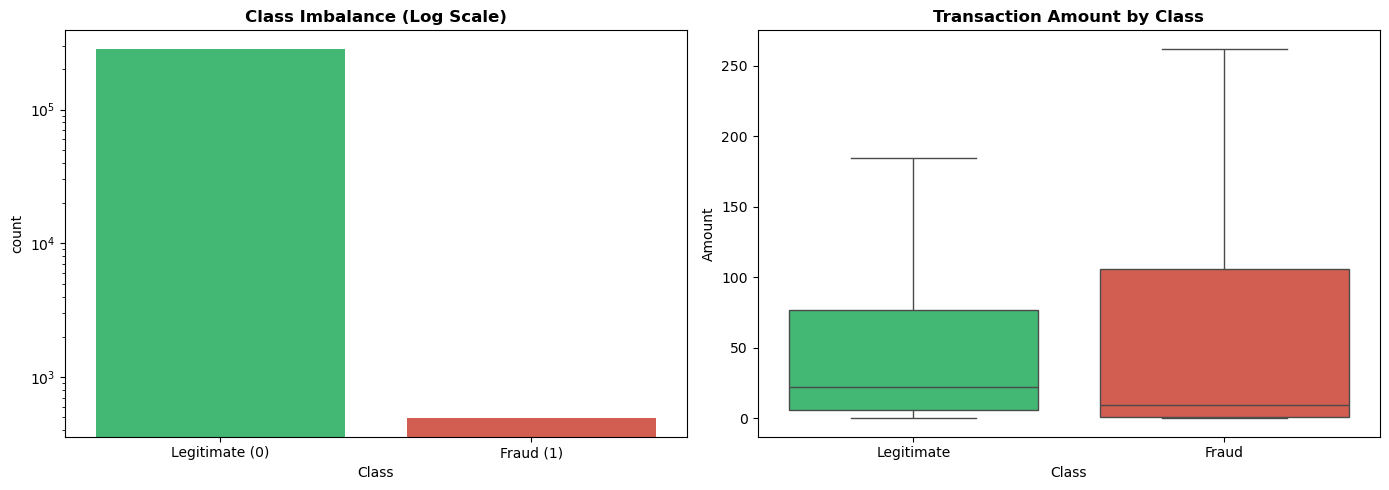

In [5]:
# Visualizing Class Imbalance and Transaction Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=credit_card_data, x='Class', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Class Imbalance (Log Scale)', fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

sns.boxplot(data=credit_card_data, x='Class', y='Amount', showfliers=False, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Transaction Amount by Class', fontweight='bold')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()
